In [22]:
import pandas as pd
import numpy as np 

TrainData = pd.read_csv("./Dados/DataSpline.csv")
TrainData.index = (np.arange(0, len(TrainData), 1).astype(float) * 0.07).round(5)
TrainData = TrainData.drop(columns=["x(Wd,We)", "y(Wd,We)"])

In [23]:
TestData = pd.read_csv("./Dados/DataSpline2.csv")
TestData.index = (np.arange(0, len(TestData), 1).astype(float) * 0.07).round(5)
TestData = TestData.drop(columns=["x(Wd,We)", "y(Wd,We)"])

In [24]:
ValData = pd.read_csv("./Dados/DataSpline3.csv")
ValData.index = (np.arange(0, len(ValData), 1).astype(float) * 0.07).round(5)
ValData = ValData.drop(columns=["x(Wd,We)", "y(Wd,We)"])

In [25]:
# Define predictors and target
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

# Convertendo para arrays numpy
train_x = TrainData[PREDICTORS].to_numpy()
train_y = TrainData[[TARGET]].to_numpy()

x_val = ValData[PREDICTORS].to_numpy()
y_val = ValData[[TARGET]].to_numpy()

x_test = TestData[PREDICTORS].to_numpy()
y_test = TestData[[TARGET]].to_numpy()

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

def compile_model(model, epochs=5000):
    # Compila e treina o modelo
    model.compile(loss="mse", optimizer="adam")
    history = model.fit(train_x, train_y, epochs=epochs, validation_data=(x_val, y_val), verbose=False)

    # Previsões
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # Cálculo das métricas
    metrics = {
        'Training': {
            'R2': r2_score(train_y, train_pred),
            'MSE': mean_squared_error(train_y, train_pred),
            'RMSE': root_mean_squared_error(train_y, train_pred),
            'MAPE': mean_absolute_percentage_error(train_y, train_pred)
        },
        'Validation': {
            'R2': r2_score(y_val, val_pred),
            'MSE': mean_squared_error(y_val, val_pred),
            'RMSE': root_mean_squared_error(y_val, val_pred),
            'MAPE': mean_absolute_percentage_error(y_val, val_pred)
        },
        'Test': {
            'R2': r2_score(y_test, test_pred),
            'MSE': mean_squared_error(y_test, test_pred),
            'RMSE': root_mean_squared_error(y_test, test_pred),
            'MAPE': mean_absolute_percentage_error(y_test, test_pred)
        }
    }

    # Imprime as métricas
    for name, m in metrics.items():
        print(f"\n{name} Metrics:")
        for k, v in m.items():
            print(f"  {k}: {v:.4f}")

    # Gráfico do histórico de treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Gráficos comparativos
    fig, axs = plt.subplots(3, 1, figsize=(12, 12))
    datasets = [
        ('Treinamento', train_y, train_pred),
        ('Validação', y_val, val_pred),
        ('Teste', y_test, test_pred)
    ]

    for i, (title, y_true, y_pred) in enumerate(datasets):
        y_true = np.ravel(y_true)
        y_pred = np.ravel(y_pred)
        axs[i].plot(y_true, marker='o', label='Amostras Reais')
        axs[i].plot(y_pred, marker='x', label='Valores Preditos')
        axs[i].set_title(f'{title}')
        axs[i].set_xlabel('Índice')
        axs[i].set_ylabel('Valor')
        axs[i].legend()
        axs[i].grid(True)

    plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return metrics


In [38]:
import keras

complex_dense_RNN  = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[2, 1]),
        keras.layers.SimpleRNN(20),
        keras.layers.Dense(1)
])


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step

Training Metrics:
  R2: 0.9215
  MSE: 0.0189
  RMSE: 0.1376
  MAPE: 1.7929

Validation Metrics:
  R2: -2.0792
  MSE: 0.7095
  RMSE: 0.8423
  MAPE: 5.8935

Test Metrics:
  R2: -6.0635
  MSE: 1.1645
  RMSE: 1.0791
  MAPE: 2.3699


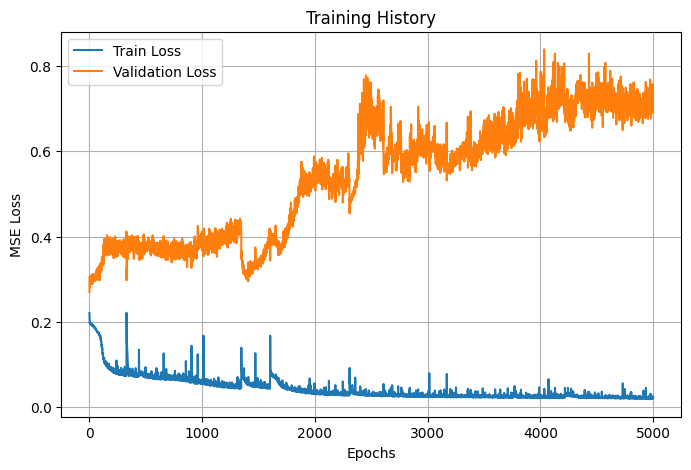

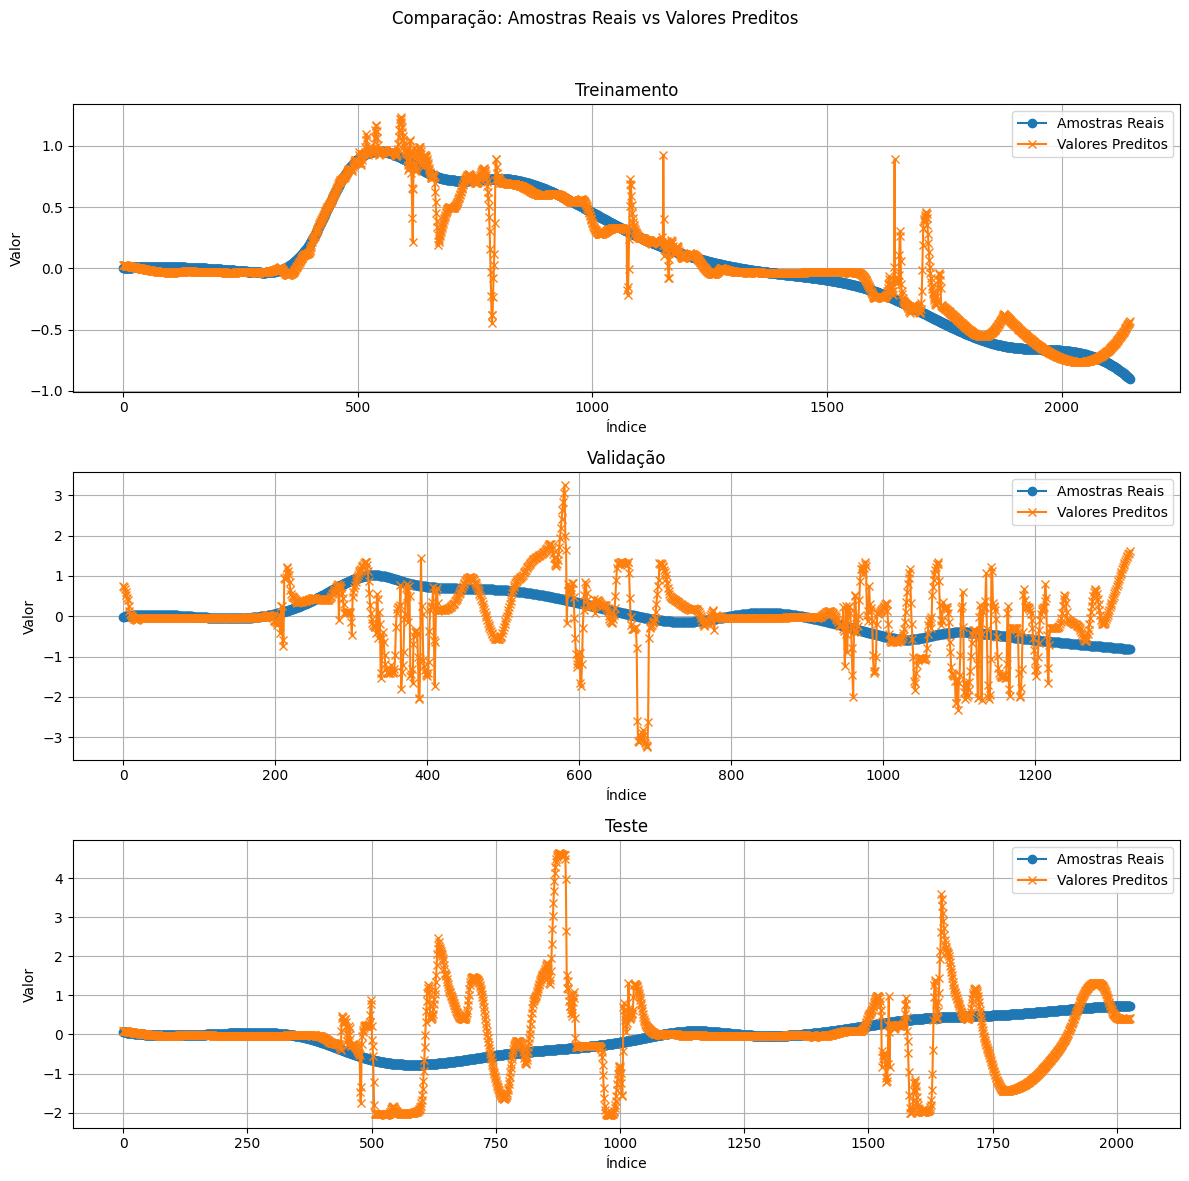

{'Training': {'R2': 0.9214721481038477,
  'MSE': 0.018935413965030998,
  'RMSE': 0.1376060099161043,
  'MAPE': 1.792917335693741},
 'Validation': {'R2': -2.079158168410642,
  'MSE': 0.7094732160183688,
  'RMSE': 0.8423023305312463,
  'MAPE': 5.893541771526633},
 'Test': {'R2': -6.06354276616901,
  'MSE': 1.164493395035398,
  'RMSE': 1.0791169515096117,
  'MAPE': 2.369891600731235}}

In [39]:
compile_model(complex_dense_RNN)